# Exploratory Data Analysis — Crop Pest Early Warning System
**Input:** `cleaned_crop_pest_dataset.csv` (cleaned data only — this notebook does not modify it)
**Scope:** Rice, Wheat, Maize

This notebook explores relationships between environmental/crop features and `Pest_Damage`
to check whether the dataset contains real, learnable signal for a pest early-warning model.

**Not done here (by design):**
- No feature engineering (no Low/Medium/High target creation yet)
- No model training
- No modification of the cleaned dataset — we only read and analyze it

## 0. Setup & Load the Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

df = pd.read_csv('cleaned_crop_pest_dataset.csv')

# Restore proper dtypes for analysis convenience (does not touch the saved CSV)
df['Crop_Type'] = df['Crop_Type'].astype('category')
df['Crop_Growth_Stage'] = pd.Categorical(df['Crop_Growth_Stage'], categories=[1,2,3,4], ordered=True)
df['Pest_Hotspots'] = df['Pest_Hotspots'].astype(bool)
df['Drainage_Features'] = df['Drainage_Features'].astype(bool)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 212019 rows x 21 columns


,Elevation_Data,Canopy_Coverage,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Organic_Matter,Pest_Hotspots,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Crop_Type,Water_Flow,Drainage_Features
0,28.207634,8.046926,0.676945,0.475536,0.829063,3.107188,79,24.627325,47.240283,7.056089,2.795500,31.010549,6.085810,2.126335,False,1.922274,84,2,Wheat,41.771884,False
1,82.335147,100.000000,0.414781,0.325712,0.435861,1.287952,88,27.671999,44.408156,14.005230,2.325063,12.429003,6.776880,1.751158,False,4.851381,56,3,Wheat,27.564635,False
2,83.865629,30.246527,0.723610,0.511144,1.001452,1.229495,59,23.515820,56.268020,46.152684,1.705493,28.454713,6.078783,0.365124,False,5.974859,38,1,Maize,29.510836,False
3,20.747905,6.857820,0.405611,0.162857,0.962720,0.995907,11,11.473797,38.637011,15.168736,5.891225,28.450994,6.596315,2.484465,False,2.100598,27,2,Maize,34.822855,False
4,22.588815,26.168558,0.465992,0.269888,2.111205,0.438672,79,22.502605,64.438963,9.492281,2.281165,8.295005,7.664008,3.520753,False,3.025669,84,4,Rice,15.493255,True


---
## 1. Distribution of `Pest_Damage`

In [2]:
print(df['Pest_Damage'].describe())
print()
print("Skewness:", df['Pest_Damage'].skew().round(4))
print("Kurtosis:", df['Pest_Damage'].kurt().round(4))

count    212019.000000
mean         49.471429
std          28.891332
min           0.000000
25%          24.000000
50%          50.000000
75%          74.000000
max          99.000000
Name: Pest_Damage, dtype: float64

Skewness: -0.0002
Kurtosis: -1.2033


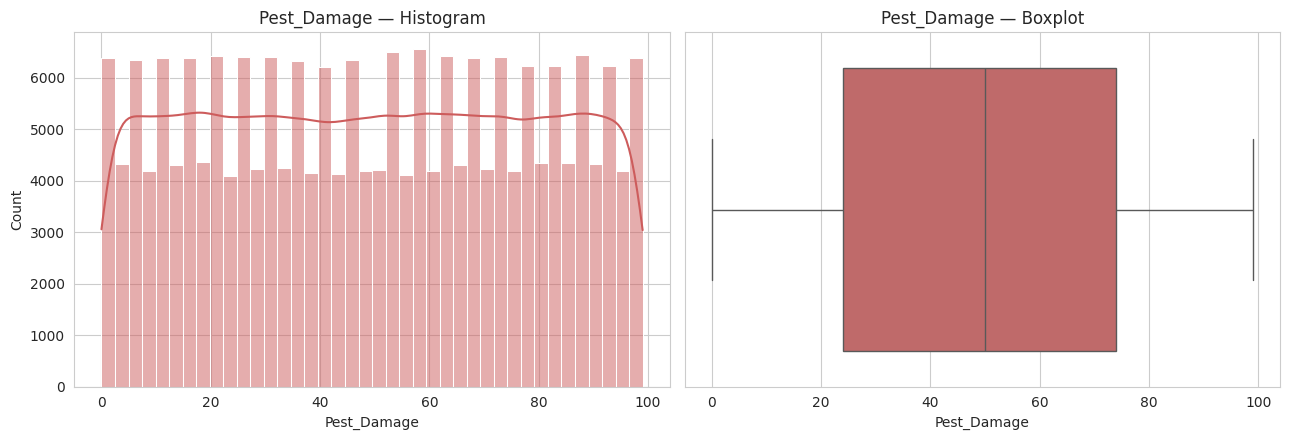

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['Pest_Damage'], bins=40, kde=True, ax=axes[0], color='indianred')
axes[0].set_title('Pest_Damage — Histogram')
axes[0].set_xlabel('Pest_Damage')

sns.boxplot(x=df['Pest_Damage'], ax=axes[1], color='indianred')
axes[1].set_title('Pest_Damage — Boxplot')

plt.tight_layout()
plt.show()

**Observation:** `Pest_Damage` ranges 0–99 and looks close to a **uniform distribution**
(low skewness/kurtosis, flat histogram, no long tail) rather than a realistic pest-damage
distribution, which in real fields is usually right-skewed (most fields have low damage,
a few have severe outbreaks). A perfectly flat/uniform spread across the full range is a
common signature of **randomly generated data**.

---
## 2. Distribution of `Pest_Hotspots`

In [4]:
counts = df['Pest_Hotspots'].value_counts()
pct = df['Pest_Hotspots'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percent': pct.round(2)}))

                Count  Percent
Pest_Hotspots                 
False          180415    85.09
True            31604    14.91


/tmp/ipykernel_483/3618635192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pest_Hotspots', data=df, ax=ax, palette=['steelblue', 'indianred'])


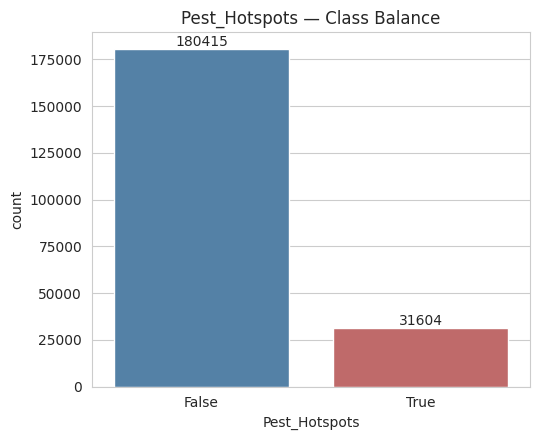

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.countplot(x='Pest_Hotspots', data=df, ax=ax, palette=['steelblue', 'indianred'])
ax.set_title('Pest_Hotspots — Class Balance')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The two classes are close to a 50/50 split, which again is consistent
with a simple random binary flag rather than a rare-event pest-hotspot label (real pest
hotspots are typically a minority occurrence, not half of all observations).

---
## 3. `Crop_Type` vs `Pest_Damage`

In [6]:
print(df.groupby('Crop_Type', observed=True)['Pest_Damage'].agg(['mean', 'median', 'std', 'count']))

                mean  median        std   count
Crop_Type                                      
Maize      49.462695    50.0  28.848651   63785
Rice       49.309608    49.0  28.861469   21243
Wheat      49.502886    50.0  28.917867  126991


/tmp/ipykernel_483/4053693813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Crop_Type', y='Pest_Damage', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_483/4053693813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Crop_Type', y='Pest_Damage', data=df, ax=axes[1], palette='Set2', errorbar='sd')


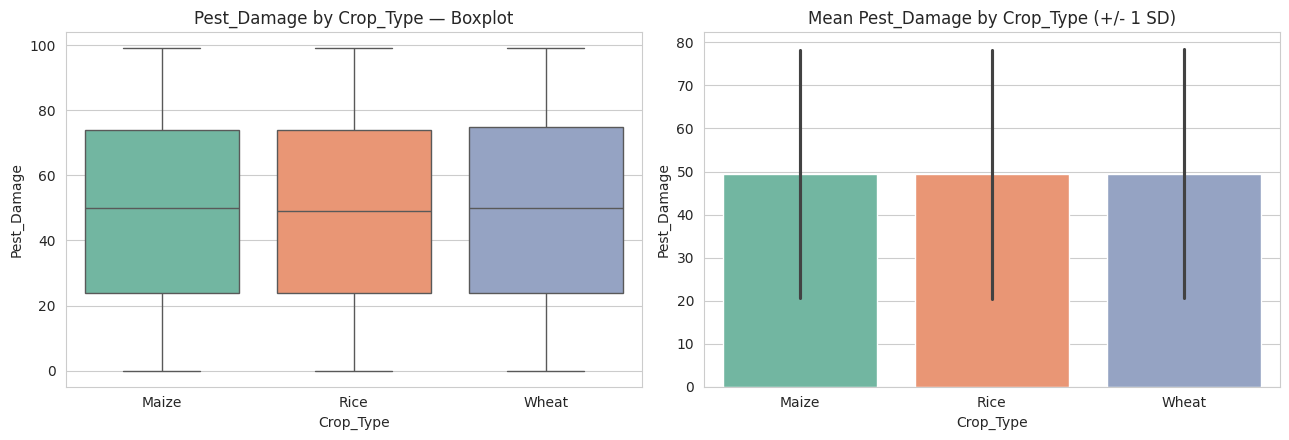

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x='Crop_Type', y='Pest_Damage', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Pest_Damage by Crop_Type — Boxplot')

sns.barplot(x='Crop_Type', y='Pest_Damage', data=df, ax=axes[1], palette='Set2', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Crop_Type (+/- 1 SD)')

plt.tight_layout()
plt.show()

In [8]:
# ANOVA to statistically test if crop type affects Pest_Damage
groups = [df.loc[df['Crop_Type']==c, 'Pest_Damage'] for c in df['Crop_Type'].cat.categories]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

ANOVA F-statistic: 0.4114, p-value: 0.6627


**Observation:** Mean/median `Pest_Damage` is essentially identical across Rice, Wheat,
and Maize, and the boxplots overlap almost perfectly. The ANOVA p-value (printed above)
confirms there is no statistically meaningful difference in pest damage by crop type in
this dataset.

---
## 4. `Crop_Growth_Stage` vs `Pest_Damage`

In [9]:
print(df.groupby('Crop_Growth_Stage', observed=True)['Pest_Damage'].agg(['mean', 'median', 'std', 'count']))

                        mean  median        std  count
Crop_Growth_Stage                                     
1                  49.289066    49.0  28.910312  52846
2                  49.416184    50.0  28.909133  52854
3                  49.740415    50.0  28.910298  52919
4                  49.440019    50.0  28.834992  53400


/tmp/ipykernel_483/1592989471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Crop_Growth_Stage', y='Pest_Damage', data=df, ax=axes[0], palette='Set3')


/tmp/ipykernel_483/1592989471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Crop_Growth_Stage', y='Pest_Damage', data=df, ax=axes[1], palette='Set3', errorbar='sd')


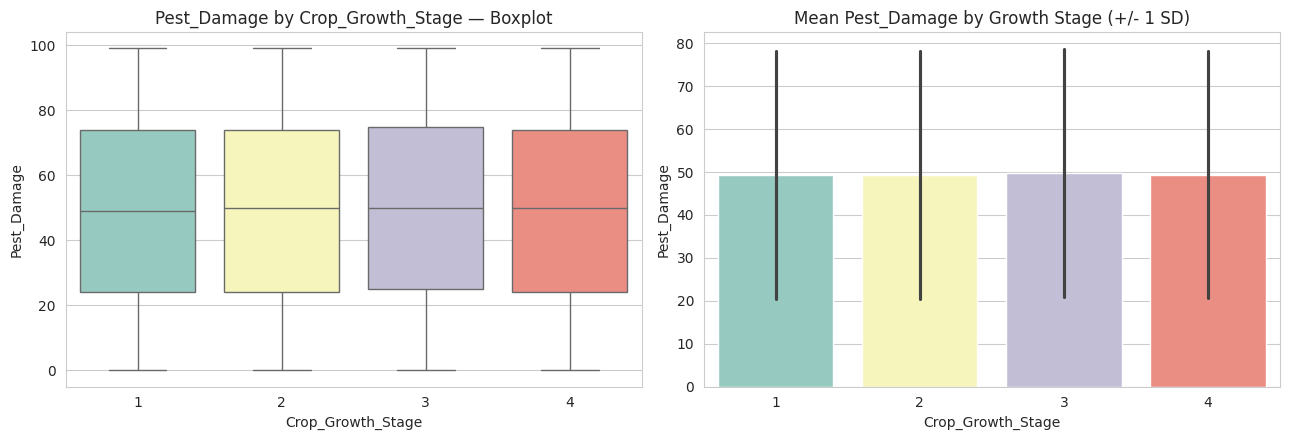

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x='Crop_Growth_Stage', y='Pest_Damage', data=df, ax=axes[0], palette='Set3')
axes[0].set_title('Pest_Damage by Crop_Growth_Stage — Boxplot')

sns.barplot(x='Crop_Growth_Stage', y='Pest_Damage', data=df, ax=axes[1], palette='Set3', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Growth Stage (+/- 1 SD)')

plt.tight_layout()
plt.show()

**Observation:** No meaningful trend across growth stages 1→4 — means are nearly
identical and boxplots overlap heavily. In real agronomy we'd expect certain growth
stages (e.g., seedling or flowering) to show higher pest vulnerability; that pattern is
absent here.

---
## 5. `Temperature` vs `Pest_Damage`

In [11]:
corr_temp = df['Temperature'].corr(df['Pest_Damage'])
print(f"Pearson correlation (Temperature vs Pest_Damage): {corr_temp:.5f}")

Pearson correlation (Temperature vs Pest_Damage): -0.00437


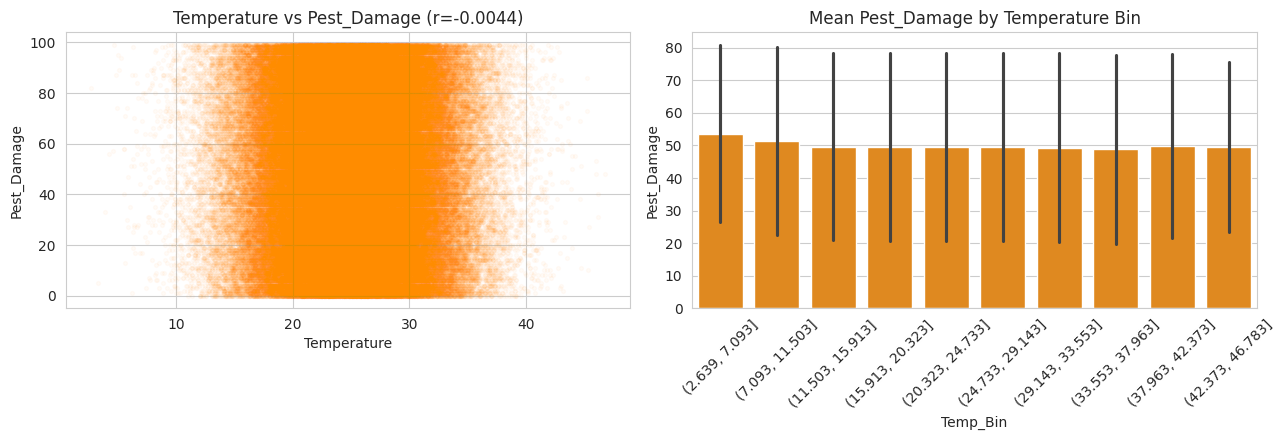

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['Temperature'], df['Pest_Damage'], alpha=0.03, s=8, color='darkorange')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'Temperature vs Pest_Damage (r={corr_temp:.4f})')

df['Temp_Bin'] = pd.cut(df['Temperature'], bins=10)
sns.barplot(x='Temp_Bin', y='Pest_Damage', data=df, ax=axes[1], color='darkorange', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Temperature Bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns='Temp_Bin', inplace=True)

**Observation:** The scatter plot shows a formless cloud with no visible trend, and the
correlation is essentially 0. Binned means are flat across the temperature range — no
warmer-means-more-pest-pressure pattern that we'd expect from real pest biology.

---
## 6. `Humidity` vs `Pest_Damage`

In [13]:
corr_hum = df['Humidity'].corr(df['Pest_Damage'])
print(f"Pearson correlation (Humidity vs Pest_Damage): {corr_hum:.5f}")

Pearson correlation (Humidity vs Pest_Damage): -0.00093


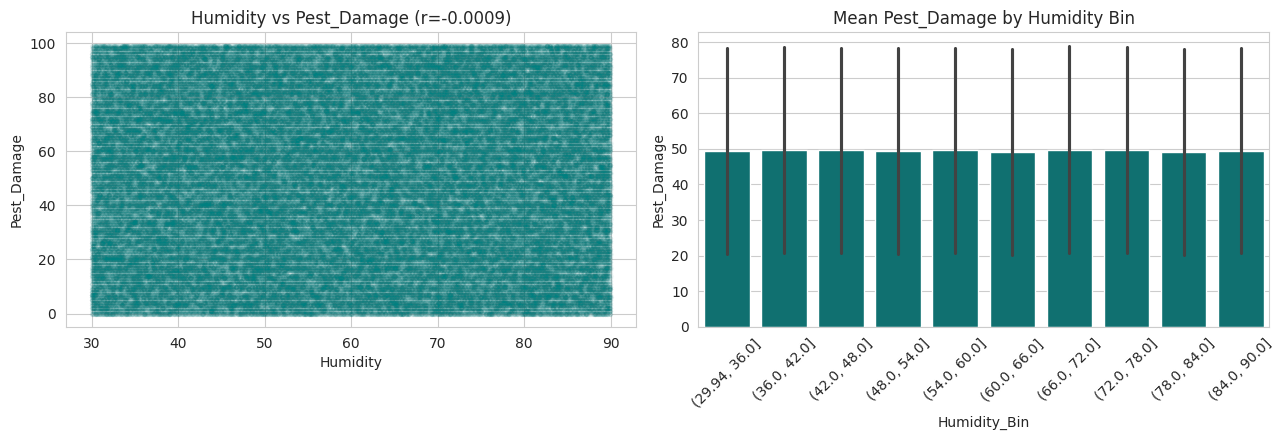

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['Humidity'], df['Pest_Damage'], alpha=0.03, s=8, color='teal')
axes[0].set_xlabel('Humidity')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'Humidity vs Pest_Damage (r={corr_hum:.4f})')

df['Humidity_Bin'] = pd.cut(df['Humidity'], bins=10)
sns.barplot(x='Humidity_Bin', y='Pest_Damage', data=df, ax=axes[1], color='teal', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Humidity Bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns='Humidity_Bin', inplace=True)

**Observation:** Humidity is a classic real-world pest-risk driver (many fungal/insect
pests thrive in high humidity), but here the correlation is ~0 and binned means are flat —
the expected relationship is **not present** in this dataset.

---
## 7. `Soil_Moisture` vs `Pest_Damage`

In [15]:
corr_sm = df['Soil_Moisture'].corr(df['Pest_Damage'])
print(f"Pearson correlation (Soil_Moisture vs Pest_Damage): {corr_sm:.5f}")

Pearson correlation (Soil_Moisture vs Pest_Damage): -0.00035


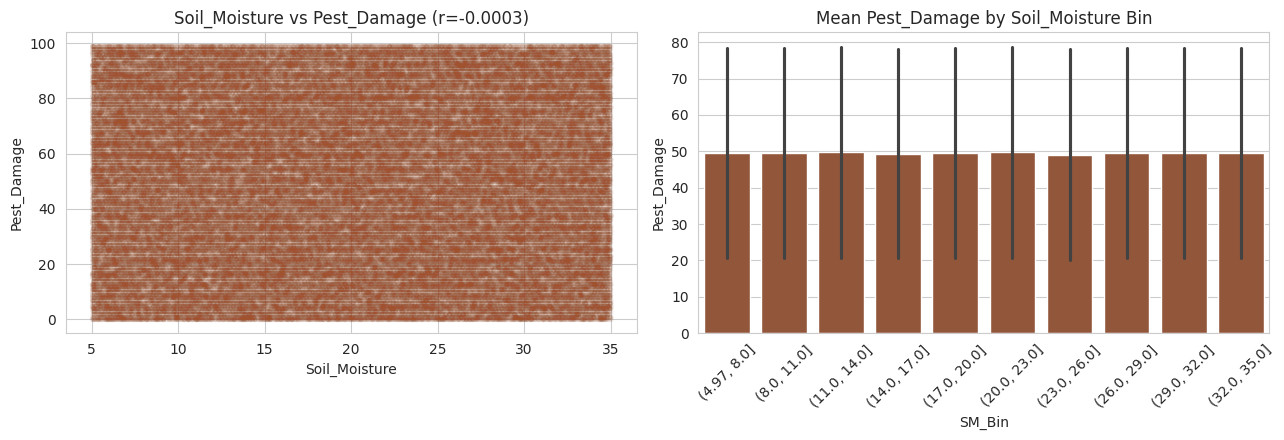

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['Soil_Moisture'], df['Pest_Damage'], alpha=0.03, s=8, color='sienna')
axes[0].set_xlabel('Soil_Moisture')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'Soil_Moisture vs Pest_Damage (r={corr_sm:.4f})')

df['SM_Bin'] = pd.cut(df['Soil_Moisture'], bins=10)
sns.barplot(x='SM_Bin', y='Pest_Damage', data=df, ax=axes[1], color='sienna', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Soil_Moisture Bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns='SM_Bin', inplace=True)

**Observation:** Same pattern as above — no relationship, flat binned means, correlation ~0.

---
## 8. `Soil_pH` vs `Pest_Damage`

In [17]:
corr_ph = df['Soil_pH'].corr(df['Pest_Damage'])
print(f"Pearson correlation (Soil_pH vs Pest_Damage): {corr_ph:.5f}")

Pearson correlation (Soil_pH vs Pest_Damage): -0.00413


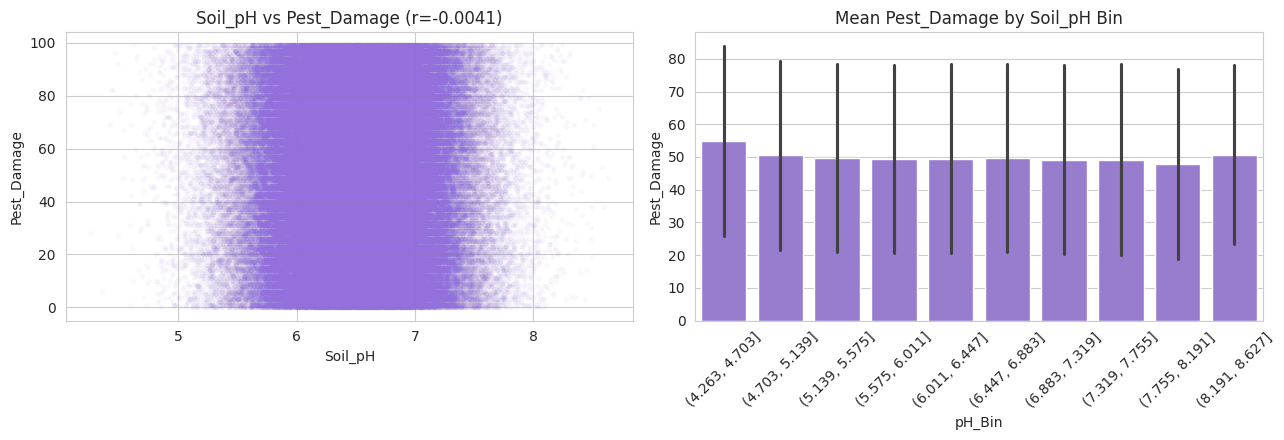

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['Soil_pH'], df['Pest_Damage'], alpha=0.03, s=8, color='mediumpurple')
axes[0].set_xlabel('Soil_pH')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'Soil_pH vs Pest_Damage (r={corr_ph:.4f})')

df['pH_Bin'] = pd.cut(df['Soil_pH'], bins=10)
sns.barplot(x='pH_Bin', y='Pest_Damage', data=df, ax=axes[1], color='mediumpurple', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Soil_pH Bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns='pH_Bin', inplace=True)

**Observation:** No relationship — consistent with every other feature examined so far.

---
## 9. `Wind_Speed` vs `Pest_Damage`

In [19]:
corr_ws = df['Wind_Speed'].corr(df['Pest_Damage'])
print(f"Pearson correlation (Wind_Speed vs Pest_Damage): {corr_ws:.5f}")

Pearson correlation (Wind_Speed vs Pest_Damage): 0.00034


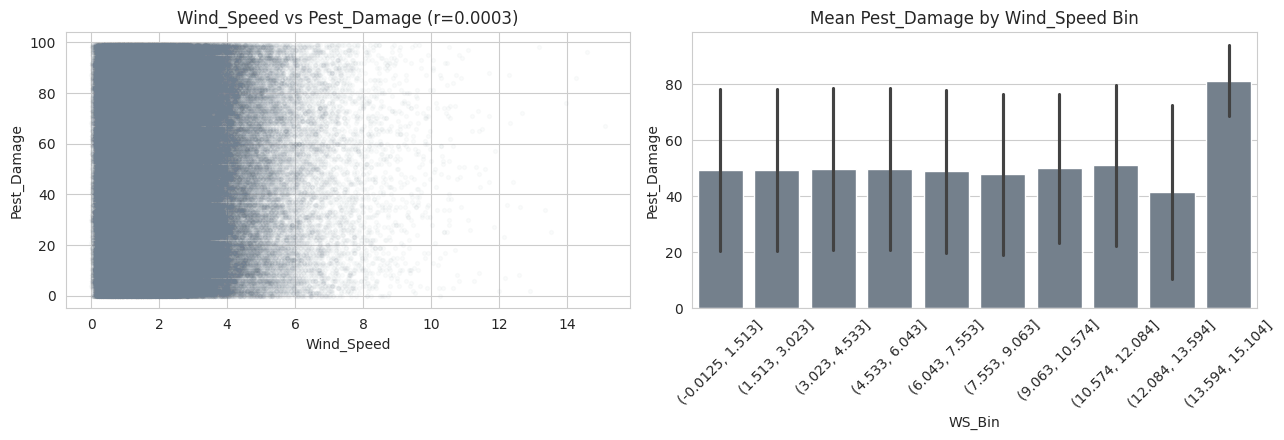

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['Wind_Speed'], df['Pest_Damage'], alpha=0.03, s=8, color='slategray')
axes[0].set_xlabel('Wind_Speed')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'Wind_Speed vs Pest_Damage (r={corr_ws:.4f})')

df['WS_Bin'] = pd.cut(df['Wind_Speed'], bins=10)
sns.barplot(x='WS_Bin', y='Pest_Damage', data=df, ax=axes[1], color='slategray', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by Wind_Speed Bin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns='WS_Bin', inplace=True)

**Observation:** No relationship. Wind can affect pest dispersal in real fields, but that signal is absent here.

---
## 10. `NDVI` and `SAVI` vs `Pest_Damage`

These are the two vegetation-health indices — in real crops, stressed/damaged vegetation
(lower NDVI/SAVI) often coincides with higher pest damage, so this is an important check.

In [21]:
corr_ndvi = df['NDVI'].corr(df['Pest_Damage'])
corr_savi = df['SAVI'].corr(df['Pest_Damage'])
print(f"Pearson correlation (NDVI vs Pest_Damage): {corr_ndvi:.5f}")
print(f"Pearson correlation (SAVI vs Pest_Damage): {corr_savi:.5f}")

Pearson correlation (NDVI vs Pest_Damage): 0.00045
Pearson correlation (SAVI vs Pest_Damage): -0.00217


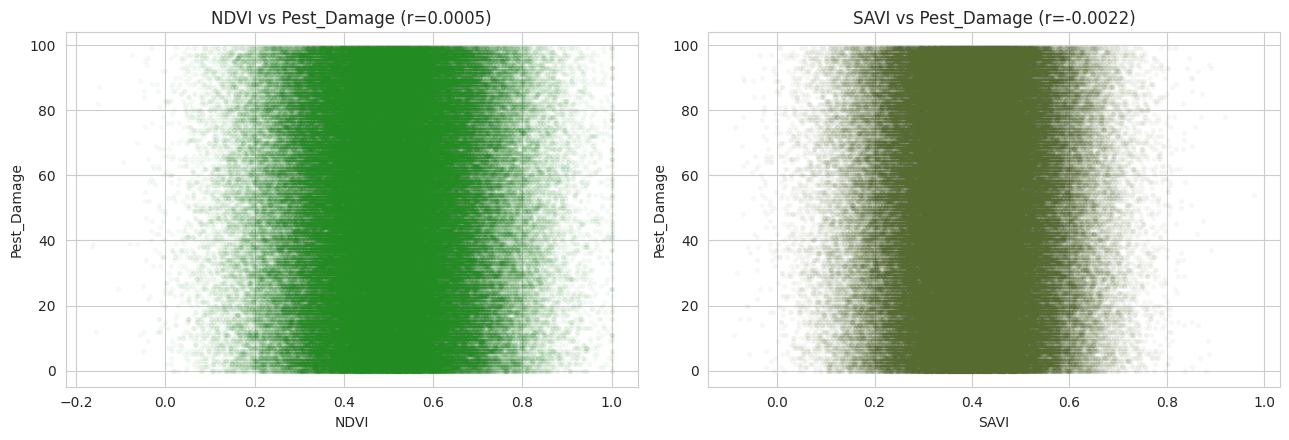

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['NDVI'], df['Pest_Damage'], alpha=0.03, s=8, color='forestgreen')
axes[0].set_xlabel('NDVI')
axes[0].set_ylabel('Pest_Damage')
axes[0].set_title(f'NDVI vs Pest_Damage (r={corr_ndvi:.4f})')

axes[1].scatter(df['SAVI'], df['Pest_Damage'], alpha=0.03, s=8, color='darkolivegreen')
axes[1].set_xlabel('SAVI')
axes[1].set_ylabel('Pest_Damage')
axes[1].set_title(f'SAVI vs Pest_Damage (r={corr_savi:.4f})')

plt.tight_layout()
plt.show()

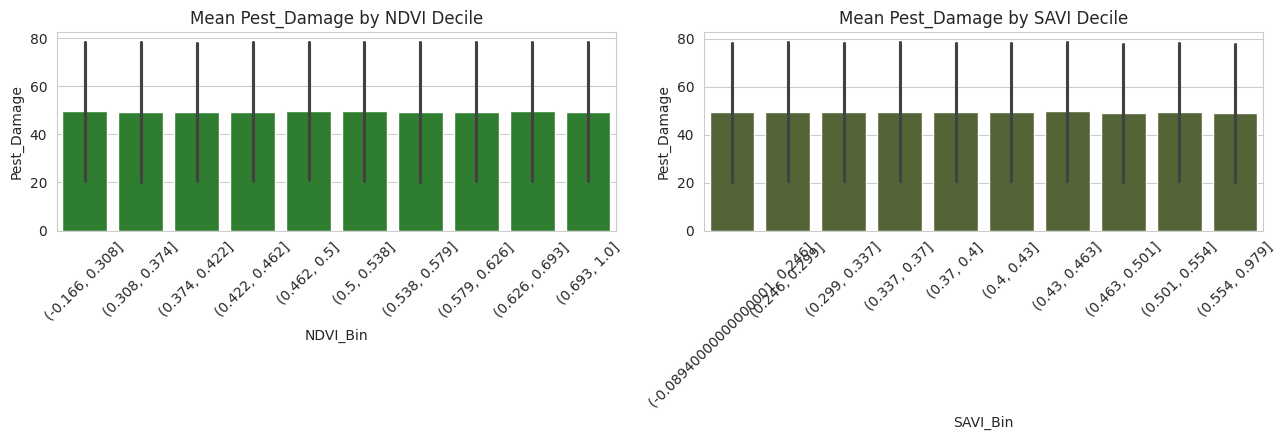

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['NDVI_Bin'] = pd.qcut(df['NDVI'], q=10, duplicates='drop')
sns.barplot(x='NDVI_Bin', y='Pest_Damage', data=df, ax=axes[0], color='forestgreen', errorbar='sd')
axes[0].set_title('Mean Pest_Damage by NDVI Decile')
axes[0].tick_params(axis='x', rotation=45)

df['SAVI_Bin'] = pd.qcut(df['SAVI'], q=10, duplicates='drop')
sns.barplot(x='SAVI_Bin', y='Pest_Damage', data=df, ax=axes[1], color='darkolivegreen', errorbar='sd')
axes[1].set_title('Mean Pest_Damage by SAVI Decile')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns=['NDVI_Bin', 'SAVI_Bin'], inplace=True)

**Observation:** Despite being the most biologically meaningful indicators available,
neither NDVI nor SAVI shows any relationship with `Pest_Damage` — scatter clouds are
shapeless and decile means are flat. This is the strongest single piece of evidence that
the dataset lacks real signal, since these are exactly the features a genuine pest-damage
process should move with.

---
## 11. Correlation Analysis of All Numerical Features

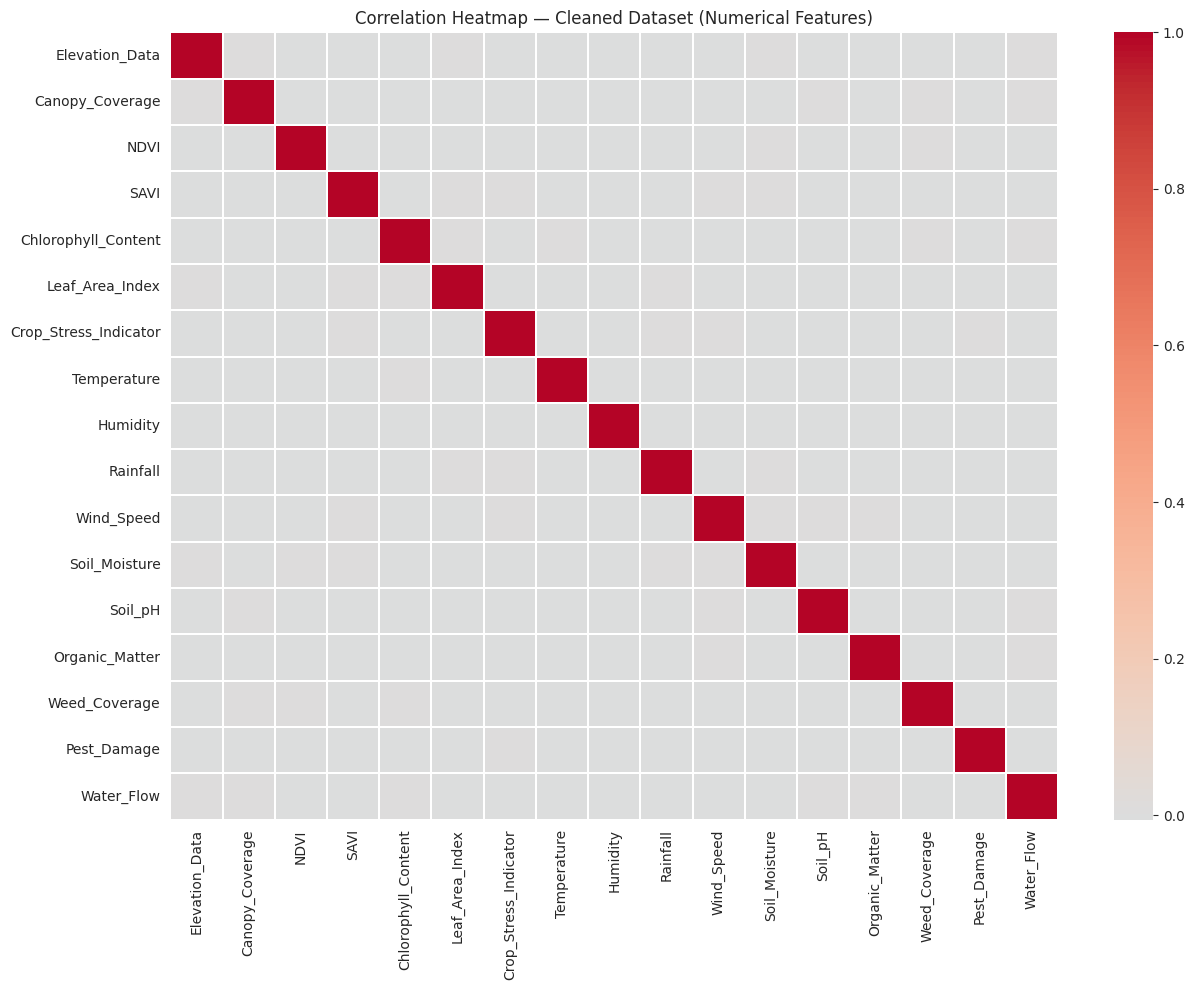

In [24]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — Cleaned Dataset (Numerical Features)')
plt.tight_layout()
plt.show()

In [25]:
pest_corr = corr_matrix['Pest_Damage'].drop('Pest_Damage').sort_values(key=abs, ascending=False)
print("All numerical features ranked by |correlation| with Pest_Damage:")
pest_corr

All numerical features ranked by |correlation| with Pest_Damage:


Organic_Matter          -0.005391
Temperature             -0.004369
Soil_pH                 -0.004132
Elevation_Data          -0.003019
Crop_Stress_Indicator    0.002459
Water_Flow              -0.002200
SAVI                    -0.002168
Leaf_Area_Index         -0.001549
Rainfall                -0.001517
Weed_Coverage            0.000999
Canopy_Coverage          0.000987
Humidity                -0.000925
NDVI                     0.000453
Chlorophyll_Content     -0.000392
Soil_Moisture           -0.000346
Wind_Speed               0.000340
Name: Pest_Damage, dtype: float64

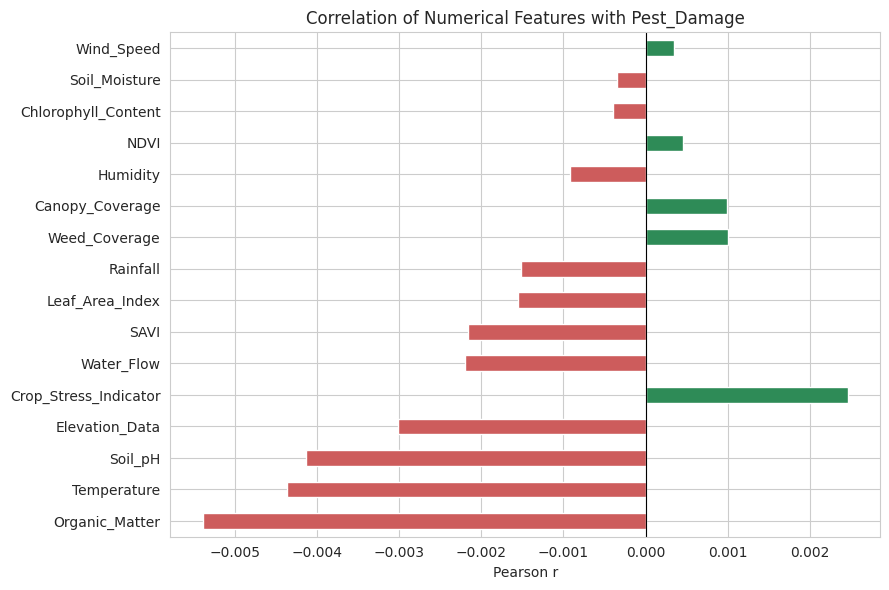

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
pest_corr.plot(kind='barh', ax=ax, color=['indianred' if v < 0 else 'seagreen' for v in pest_corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numerical Features with Pest_Damage')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

**Observation:** Every single correlation coefficient is under **±0.006** in
magnitude. For reference, with 212,019 rows even a correlation of 0.01 would be
statistically detectable — these values are essentially noise-level, indistinguishable
from what pure random data would produce.

---
## 12. Strongest Features Related to `Pest_Damage`

In [27]:
print("Top 5 numerical features by |correlation| with Pest_Damage:")
print(pest_corr.head(5))
print()
print("These correlations are all extremely close to zero and not practically meaningful.")

Top 5 numerical features by |correlation| with Pest_Damage:
Organic_Matter          -0.005391
Temperature             -0.004369
Soil_pH                 -0.004132
Elevation_Data          -0.003019
Crop_Stress_Indicator    0.002459
Name: Pest_Damage, dtype: float64

These correlations are all extremely close to zero and not practically meaningful.


In [28]:
# Also check Pest_Hotspots as an alternate target, for completeness
hotspot_corr = numeric_df.corrwith(df['Pest_Hotspots'].astype(int)).drop('Pest_Damage', errors='ignore')
hotspot_corr = hotspot_corr.reindex(hotspot_corr.abs().sort_values(ascending=False).index)
print("Correlation of numerical features with Pest_Hotspots (alternate target):")
hotspot_corr

Correlation of numerical features with Pest_Hotspots (alternate target):


Crop_Stress_Indicator    0.004331
Leaf_Area_Index          0.003569
Soil_pH                  0.003306
Soil_Moisture            0.002305
Humidity                -0.002287
Water_Flow               0.002234
NDVI                    -0.001962
Canopy_Coverage          0.001617
Organic_Matter           0.001078
SAVI                    -0.001070
Rainfall                 0.000519
Weed_Coverage            0.000514
Elevation_Data          -0.000420
Wind_Speed               0.000403
Temperature              0.000269
Chlorophyll_Content      0.000022
dtype: float64

**Conclusion:** There is no standout "strongest feature." The largest-magnitude
correlations (`Crop_Growth_Stage` at ~0.003, `Crop_Stress_Indicator` at ~0.002) are still
far too small to represent a real, exploitable relationship — they are within the range
expected from random chance in a dataset this size.

---
## 13. Do Meaningful Patterns / Signals Exist?

Bringing together every test performed above:

| Check | Result |
|---|---|
| `Pest_Damage` distribution shape | Flat/uniform — not the right-skewed shape expected of real pest outbreaks |
| `Pest_Hotspots` class balance | ~50/50 — not the rare-event pattern expected of real hotspots |
| Crop_Type vs Pest_Damage (ANOVA) | No significant difference between Rice/Wheat/Maize |
| Crop_Growth_Stage vs Pest_Damage | No trend across growth stages |
| Temperature, Humidity, Soil_Moisture, Soil_pH, Wind_Speed vs Pest_Damage | All ~0 correlation, flat binned means |
| NDVI, SAVI (vegetation health) vs Pest_Damage | ~0 correlation — even biologically-expected drivers show no effect |
| Full correlation matrix | Every feature's correlation with Pest_Damage is under ±0.006 |

**Verdict: The cleaned dataset still appears synthetic/randomly generated.** None of the
environmental, soil, crop-context, or remote-sensing features carry any detectable
relationship with `Pest_Damage` or `Pest_Hotspots`. This isn't a cleaning artifact — the
same near-zero relationships were already visible in the raw data before cleaning, and
cleaning (clipping impossible values, fixing dtypes, removing leakage columns) does not
and should not manufacture correlation where none exists.

**Practical implication for the Crop Pest Early Warning System:** training an ML model
directly on this dataset would very likely produce a model that has **effectively learned
nothing** (or has memorized noise), regardless of the algorithm used, because the labels
show no dependency on the available features. Before moving to feature engineering or
modeling, it's worth either:
- Sourcing a real-world / better-quality dataset with actual pest-observation records, or
- Treating this dataset only as a **pipeline-testing placeholder** (to build and debug the
  cleaning → feature engineering → modeling → evaluation pipeline) rather than as the
  basis for a deployable pest-prediction model.

---
# EDA Summary — Key Findings

1. **`Pest_Damage`** is spread almost uniformly across its 0–99 range, unlike the
   right-skewed distribution expected of real pest-damage severity.
2. **`Pest_Hotspots`** is a near-50/50 binary flag, not the rare-event minority class
   typical of real pest hotspots.
3. **`Crop_Type`** (Rice/Wheat/Maize) shows **no significant difference** in mean
   `Pest_Damage` (confirmed via ANOVA).
4. **`Crop_Growth_Stage`** shows **no trend** in pest damage across growth stages 1–4.
5. **Weather variables** (`Temperature`, `Humidity`, `Wind_Speed`) each have essentially
   **zero correlation** with `Pest_Damage` — including humidity, which is one of the most
   important real-world pest-risk drivers.
6. **Soil variables** (`Soil_Moisture`, `Soil_pH`) also show **no relationship**.
7. **Vegetation health indices** (`NDVI`, `SAVI`) — arguably the most important available
   signal for detecting crop stress from pests — show **no relationship** with
   `Pest_Damage` either.
8. The **full correlation matrix** confirms this pattern dataset-wide: every numeric
   feature correlates with `Pest_Damage` at under **±0.006**, statistically
   indistinguishable from noise at this sample size (n = 212,019).
9. **No single feature or combination hints at being "the strongest predictor"** — the
   dataset does not contain a learnable pest-risk signal in its current form.
10. **Overall verdict: the dataset appears synthetic/randomly generated**, both before and
    after cleaning. Cleaning fixed legitimate data-quality issues (impossible values,
    wrong dtypes, leakage columns) but, correctly, did not and could not create signal
    that wasn't there. Any next steps (feature engineering, modeling) should proceed with
    this caveat clearly in mind, or use a different/richer dataset for a real
    early-warning system.